In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform

In [5]:
Q = np.array(
    [
        [-10.0, 19.7365809, 19.7365809, 5.42015853, 5.42015853],
        [19.7365809, -10.0, 20.67626392, 0.17675796, 0.85604541],
        [19.7365809, 20.67626392, -10.0, 0.85604541, 0.17675796],
        [5.42015853, 0.17675796, 0.85604541, -10.0, 0.32306662],
        [5.42015853, 0.85604541, 0.17675796, 0.32306662, -10.0],
    ]
)

print(len(Q))

5


In [4]:
bitstrings = [np.binary_repr(i, len(Q)) for i in range(2 ** len(Q))]
costs = []

for b in bitstrings:
    z = np.array(list(b), dtype=int)
    cost = z.T @ Q @ z
    costs.append(cost)
zipped = zip(bitstrings, costs)
sort_zipped = sorted(zipped, key=lambda x: x[1])
print(sort_zipped[:3])

[('01011', np.float64(-27.288260020000003)), ('00111', np.float64(-27.288260019999996)), ('00101', np.float64(-19.64648408))]


In [7]:
device = pulser.DigitalAnalogDevice
device.print_specs()

----------------------------------
DigitalAnalogDevice Specifications
----------------------------------
A device with digital and analog capabilites.

Register parameters:
 - Dimensions: 2D
 - Maximum number of atoms: 100
 - Maximum distance from origin: 50 µm
 - Minimum distance between neighbouring atoms: 4 μm

Layout parameters:
 - Requires layout: Yes
 - Accepts new layout: Yes
 - Minimal number of traps: 1
 - Minimum layout filling fraction: 0.0
 - Maximum layout filling fraction: 0.5

Device parameters:
 - Rydberg level: 70
 - Ising interaction coefficient: 5420158.53
 - Channels can be reused: No
 - Supported bases: ground-rydberg, digital
 - Supported states: r, g, h
 - SLM Mask: Yes

Channels:
 - 'rydberg_global': Rydberg(addressing='Global',
        max_abs_detuning=125.66370614359172,
        max_amp=15.707963267948966,
        min_retarget_interval=None,
        fixed_retarget_t=None,
        max_targets=None,
        clock_period=4,
        min_duration=16,
        max_du

In [8]:
def evaluate_mapping(
        new_coords: np.ndarray, Q: np.ndarray, device: pulser.devices.Device
):
    """ Cost function to minimize """
    new_coords = np.reshape(new_coords, (len(Q), 2))
    new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
    return np.linalg.norm(new_Q - Q)

costs = []
np.random.seed(0)
x0 = np.random.random(len(Q) * 2)
res = minimize(
    evaluate_mapping,
    x0,
    args=(Q, device),
    method="Nelder-Mead",
    tol=1e-6,
    options={"maxiter": 200000, "maxfev": None},
)

coords = np.reshape(res.x, (len(Q), 2))

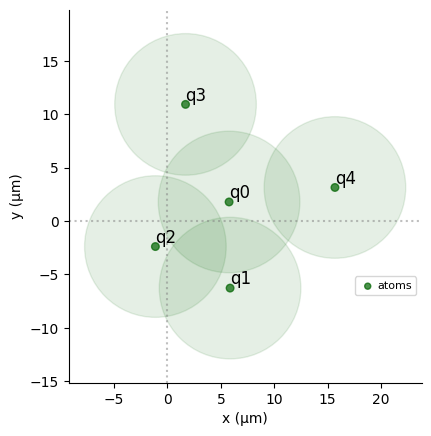

In [10]:
qubits = {f"q{i}": coord for (i, coord) in enumerate(coords)}
reg = pulser.Register(qubits)
reg.draw(
    blockade_radius=device.rydberg_blockade_radius(1.0),
    draw_graph=False,
    draw_half_radius=True,
)

In [13]:
sequence = pulser.Sequence(reg, device)
sequence.declare_channel("rydberg_global", "rydberg_global")

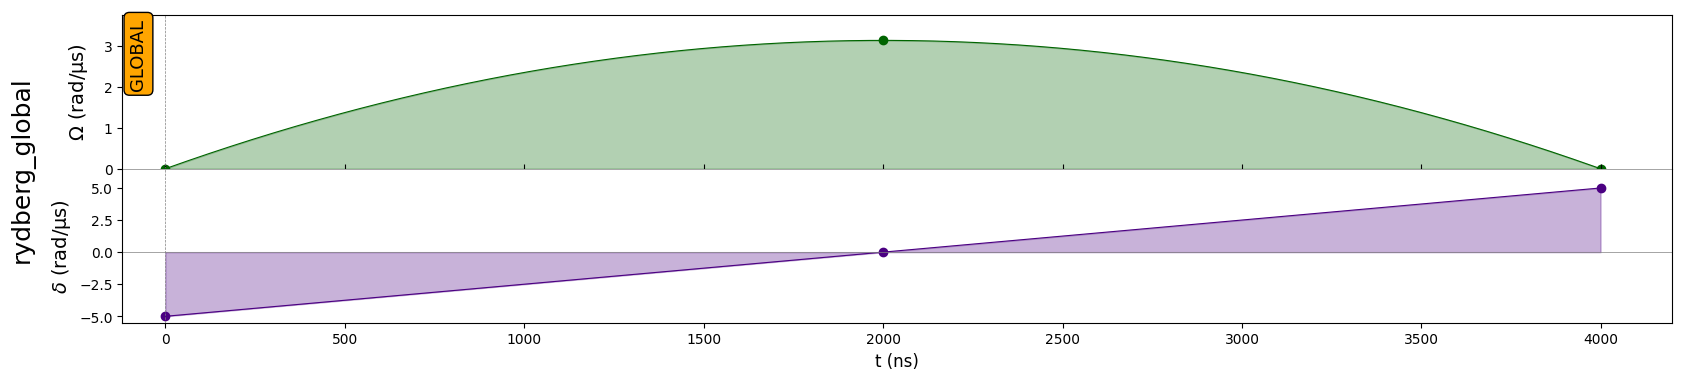

In [14]:
Omega = np.median(Q[Q > 0].flatten()) # On ignore là où la matrice est nulle
delta_0 = -5 # just has to be negative
delta_f = - delta_0 
T = 4000 # Assez de temps

adiabatic_pulse = pulser.Pulse(
    pulser.InterpolatedWaveform(T, [1e-9, Omega, 1e-9]),
    pulser.InterpolatedWaveform(T, [delta_0, 0, delta_f]),
    0,
)

sequence.add(adiabatic_pulse, "rydberg_global")
sequence.draw()

In [15]:
simul = pulser_simulation.QutipBackendV2(sequence)
results = simul.run()
count_dict = results.final_bitstrings

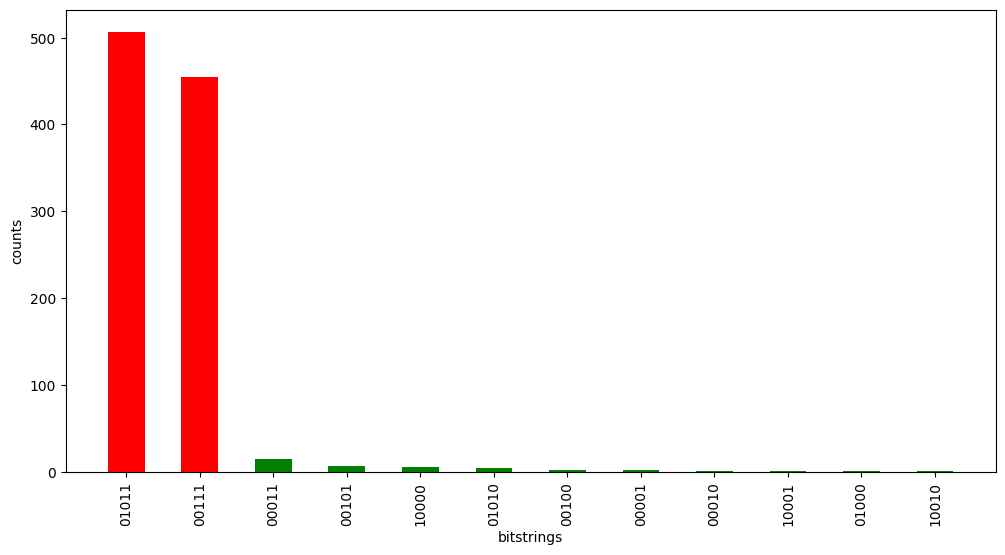

In [17]:
count_dict = dict(
    sorted(count_dict.items(), key=lambda item: item[1], reverse = True)
)

indexes = ["01011","00111"] # QUBO solution
color_dict = {key: "r" if key in indexes else "g" for key in count_dict}

plt.figure(figsize=(12,6))
plt.xlabel("bitstrings")
plt.ylabel("counts")
plt.bar(
    count_dict.keys(),
    count_dict.values(),
    width=0.5,
    color=color_dict.values(),
)

plt.xticks(rotation="vertical")
plt.show()

In [ ]:
# The bitstrings 01011 and 00111 (in red) correspond to the two optimal solutions (calculated at the beginning of the notebook). See how fast and performant this method is! In only a few micro-seconds, we find an excellent solution.

In [21]:
# How does the time evolution affect the quality of the results?
def get_cost_colouring(bitstring, Q):
    z = np.array(list(bitstring), dtype=int)
    cost = z.T @ Q @ z
    return cost

def get_cost(counter, Q):
    cost = sum(counter[key] * get_cost_colouring(key, Q) for key in counter)
    return cost / sum(counter.values())

In [24]:
cost = []
for T in 1000 * np.linspace(1, 10, 10):
    seq = pulser.Sequence(reg, pulser.DigitalAnalogDevice)
    seq.declare_channel("ising", "rydberg_global")
    adiabatic_pulse = pulser.Pulse(
        pulser.InterpolatedWaveform(T, [1e-9, Omega, 1e-9]),
        pulser.InterpolatedWaveform(T, [delta_0, 0, delta_f]),
        0
    )
    seq.add(adiabatic_pulse, "ising")
    simul = pulser_simulation.QutipBackendV2(seq)
    results = simul.run()
    count_dict = results.final_bitstrings
    cost.append(get_cost(count_dict, Q)/3) #Pq / 3 ici : Juste pour ramené le min à -9 plutôt que -27 ? ...

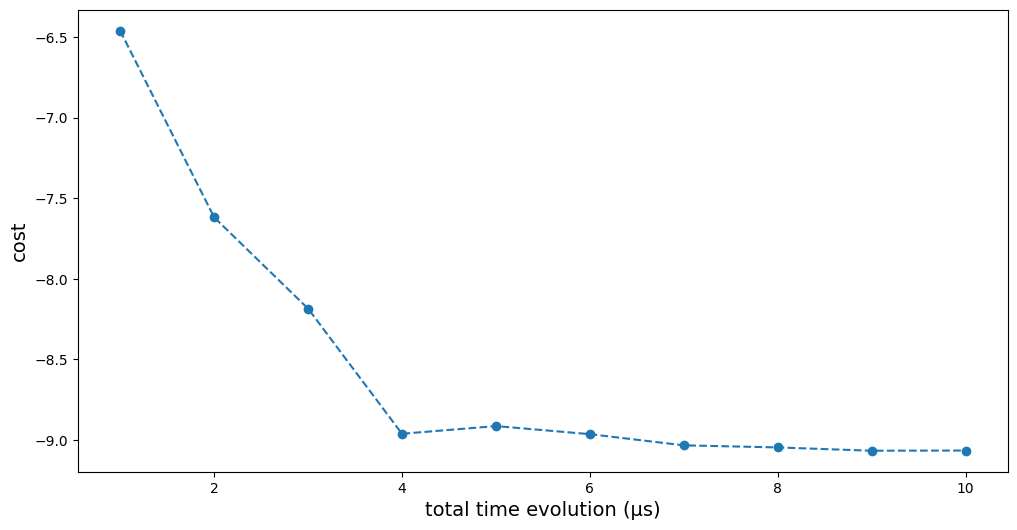

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), np.array(cost), "--o")
plt.xlabel("total time evolution (µs)", fontsize=14)
plt.ylabel("cost", fontsize=14)
plt.show()

In [ ]:
# We see why this approach is called “Adiabatic”: the quality of the solution increases (the cost decreases) if the time taken for the evolution is longer.